### **Задания 16,17,20**
16. Рассчитать на выбранном в п. 12 историческом окне для отобранных акций ковариационную матрицу на основе скорректированных $\beta$ (adjusted betas)
17. Построить границу эффективных портфелей на основе полученной в п. 16 ковариационной матрицы18. (*) Построить границу эффективных портфелей для разных исторических окон и продемонстрировать динамику её изменений
19. Сравнивать на выбранном в п. 12 историческом окне для отобранных акций границы эффективных портфелей, рассчитанные тремя разными способами: на основе исторических доходностей, исторических и скорректированных betas. Привести экономическую интерпретацию полученных результатов

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_stocks = pd.read_csv("data/moex_close_prices_wide_2015_2025.csv")
df_stocks = df_stocks.set_index("date")
df_stocks.index = df_stocks.index.astype("datetime64[ns]")

df_stocks.head()

,AFKS,AFLT,ALRS,BSPB,CHMF,GAZP,GMKN,LKOH,MAGN,MGNT,...,SBER,SBERP,SELG,SIBN,SNGS,SNGSP,TATN,TATNP,TRNFP,VTBR
date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,12.25,33.21,60.38,24.60,522.00,133.95,85.90,2295.0,11.279,9877.0,...,56.37,38.59,4.595,142.0,24.240,29.600,238.00,134.7,1301.0,337.50
2015-01-06,12.37,33.07,61.28,25.60,556.90,138.92,91.01,2345.0,11.550,10400.0,...,58.28,39.50,4.500,144.6,25.015,30.195,228.75,135.3,1429.9,333.30
2015-01-08,12.60,35.17,60.20,26.50,542.70,146.46,95.50,2572.0,12.350,10627.0,...,65.70,43.75,4.595,148.1,26.265,31.600,245.00,136.0,1300.0,337.05
2015-01-09,12.61,34.00,61.91,26.15,548.55,141.70,97.40,2461.0,12.100,10542.0,...,63.10,42.90,4.555,146.6,25.650,32.010,234.05,134.5,1208.2,326.55
2015-01-12,12.13,34.45,63.00,25.70,558.45,140.22,98.39,2477.0,11.893,10689.0,...,62.90,42.41,4.650,143.1,25.450,31.360,228.25,133.3,1280.0,317.65


In [20]:
def find_stock_returns(df_stocks: pd.DataFrame) -> pd.DataFrame:
    """
    Найти доходности активов (акций) по дням

    Args:
        df_stocks (pandas.DataFrame): датафрейм с ценами акций
    """
    df_diff = (df_stocks - df_stocks.shift(1))
    df_returns = df_diff / df_stocks
    
    df_returns = df_returns.dropna()
    return df_returns

In [109]:
from typing import Literal


def find_market_portfolio_returns(
    df_returns: pd.DataFrame,
    return_type: Literal["series", "dataframe"] = "series"
):
    """
    Найти доходность рыночного портфеля в прошлом
    """
    series_market = df_returns.mean(axis=1)
    if return_type == "series":
        return series_market

    df_market = pd.DataFrame(
        series_market, columns=["MOEX30"]
    )
    return df_market

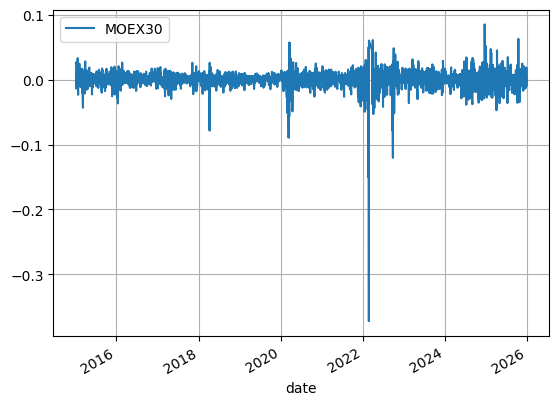

In [116]:
df_returns = find_stock_returns(df_stocks)
df_market = find_market_portfolio_returns(df_returns, "dataframe")
df_market.plot(y="MOEX30")
plt.grid()
plt.show()

### **Исторические и скорректированные (adjusted) $\beta$**

Общее соотношение:
$$
\beta_{i, t+1} = \alpha_0 + \alpha_1 \cdot \beta_{i,t} + \epsilon_{i, t+1}
$$

Общая оценка:
$$
\beta_{i, t+1} = \hat{\alpha_0} + \hat{\alpha_1} \cdot \beta_{i,t}
$$

Blume Adjustment
$$
\alpha_0 = 0.333 \hspace{1cm} \alpha_1 = 0.666
$$

In [118]:
from typing import Literal


def estimate_betas(
    df_returns: pd.DataFrame,
    start_month: str,
    end_month: str,
    method: Literal["historical", "adjusted"] = "historical",
):
    if method not in ["historical", "adjusted"]:
        raise ValueError("Unsupported beta estimation method: {0}".format(method))

    df = df_returns.copy()
    df = df.loc[start_month:end_month]

    df["MOEX30"] = find_market_portfolio_returns(df, "series")
    df_cov = df.cov().filter(["MOEX30"]).drop(index=["MOEX30"])
    market_var = df.var(axis=0).get("MOEX30")

    df_beta = df_cov / market_var
    df_beta = df_beta.rename(columns={"MOEX30": "beta"})
    
    if method == "historical":
        return df_beta

    # Adjusted beta estimation
    alpha0 = 0.333
    alpha1 = 0.666
    df_beta["beta"] = alpha0 + alpha1 * df_beta["beta"]
    return df_beta

### **Экономическая интерпретация $\beta$**
- $\beta < 0$ $\rightarrow$ актив идёт против рынка (бывает редко)
- $\beta = 0$ $\rightarrow$ актив независим от рынка и имеет почти нулевой риск
- $\beta < 1$ $\rightarrow$ актив менее волатильный по сравнению с рынком (более защищённый)
- $\beta = 1$ $\rightarrow$ актив движется как рынок (Пример: IMOEX)
- $\beta > 1$ $\rightarrow$ актив более волатилен по сравнению с рынком 

In [175]:
def find_beta_cov_matrix(
    df_returns: pd.DataFrame,
    start_month: str,
    end_month: str,
    beta_method: str = "historical",
):
    df = df_returns.copy()
    
    df_beta = estimate_betas(df, start_month, end_month, method=beta_method)
    market_var = find_market_portfolio_returns(
        df, return_type="series" 
    ).var()
    
    df_var = pd.DataFrame(
        market_var * np.outer(df_beta.values, df_beta.values),
        index=df_beta.index, columns=df_beta.index
    )
    return df_var

In [176]:
def find_historical_cov_matrix(
    df_returns: pd.DataFrame,
    start_month: str,
    end_month: str
):
    df = df_returns.loc[start_month:end_month]
    df = df.copy()
    return df.cov()

In [182]:
from typing import Literal


def find_returns_cov(
    df_returns,
    start_month: str,
    end_month: str,
    method: Literal["historical", "beta_historical", "beta_adjusted"]
):
    if method == "historical":
        return find_historical_cov_matrix(
            df_returns, start_month, end_month
        )
    elif method == "beta_historical":
        return find_beta_cov_matrix(
            df_returns, start_month, end_month, beta_method="historical"
        )
    elif method == "beta_adjusted":
        return find_beta_cov_matrix(
            df_returns, start_month, end_month, beta_method="adjusted"
        )

    raise ValueError("Unsupported method: {0}".format(method))

In [243]:
def find_returns_mu(
    df_returns: pd.DataFrame,
    start_month: str,
    end_month: str,
):
    df = df_returns.loc[start_month:end_month]
    df = pd.DataFrame(df.mean(axis=0), columns=["mu"])
    return df

In [184]:
df_test = df_returns[["SBER", "VTBR"]]

find_returns_cov(
    df_test, 
    start_month="2025-01", 
    end_month="2025-12",
    method="beta_adjusted"
)

,SBER,VTBR
SBER,0.000241,0.000440
VTBR,0.000440,0.000801


#### **Границы эффективных потрфелей**

In [160]:
def portfolio_return(weights, mu):
    return np.dot(weights, mu)


def portfolio_volatility(weights, cov):
    return np.sqrt(weights @ cov @ weights)


def portfolio_sharpe(weights, mu, cov):
    ret = portfolio_return(weights, mu)
    vol = portfolio_volatility(weights, cov)
    return ret / vol if vol > 0 else 0

In [282]:
from scipy.optimize import minimize


def find_effective_frontier(
    df_returns: pd.DataFrame,
    start_month: str,
    end_month: str,
    cov_method: Literal["historical", "beta_historical", "beta_adjusted"]
):
    mu = df_returns.loc[start_month:end_month].mean(axis=0)
    mu = mu.values
    
    cov = find_returns_cov(df_returns, start_month, end_month, method=cov_method)
    cov = cov.values

    # Решаем набор оптимизационных задач
    min_return = np.min(mu)
    max_return = np.max(mu)
    returns_arr = np.linspace(min_return, max_return, 50)

    n_assets = mu.size
    w0 = np.full(n_assets, fill_value = 1 / n_assets)

    # Точки на границе
    frontier_returns = []
    frontier_volatilities = []
    
    for target in returns_arr:
        result = minimize(
            lambda w: portfolio_volatility(w, cov),
            x0=w0,
            bounds=[(0, None) for _ in w0],
            constraints=[
                {"type": "eq", "fun": lambda w: np.sum(w) - 1},
                {"type": "eq", "fun": lambda w: portfolio_return(w, mu) - target}
            ],
            options={
                "maxiter": 1000
            }
            
        )

        if not result.success:
            continue

        w = result.x
        frontier_returns.append(portfolio_return(w, mu))
        frontier_volatilities.append(portfolio_volatility(w, cov))

    return frontier_volatilities, frontier_returns 

### **Сравнение для 2025 года**

In [287]:
np.random.seed(2025)

start_month = "2025-01"
end_month = "2025-12"

sigmas1, alphas1 = find_effective_frontier(
    df_returns,
    start_month=start_month,
    end_month=end_month,
    cov_method="historical"
)

sigmas2, alphas2 = find_effective_frontier(
    df_returns,
    start_month=start_month,
    end_month=end_month,
    cov_method="beta_historical"
)

sigmas3, alphas3 = find_effective_frontier(
    df_returns,
    start_month=start_month,
    end_month=end_month,
    cov_method="beta_adjusted"
)

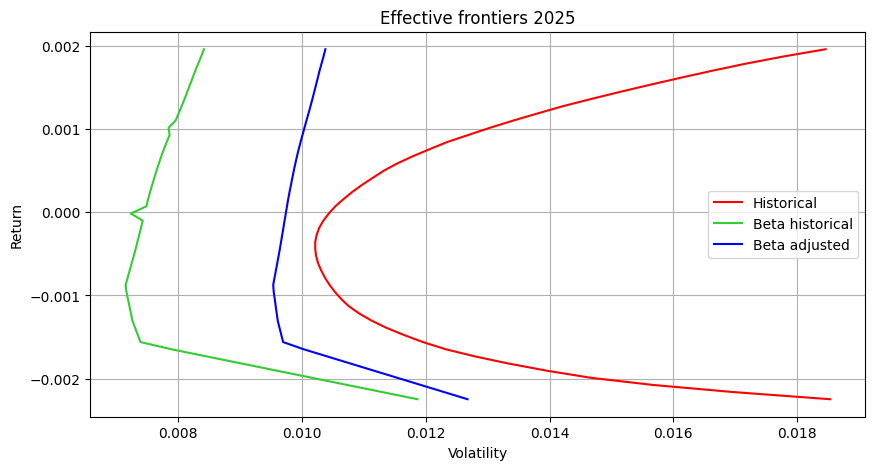

In [299]:
plt.figure(figsize=(10, 5))


plt.plot(sigmas1, alphas1, color='red', label="Historical")
plt.plot(sigmas2, alphas2, color='limegreen', label="Beta historical")
plt.plot(sigmas3, alphas3, color='blue', label="Beta adjusted")

plt.grid(True)
plt.legend()

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Effective frontiers 2025")

plt.savefig("Effective-frontiers-2025.pdf", format="pdf")
plt.show()